In [ ]:
import sys
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install category_encoders

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [ ]:
print("laptop cost estimate")

laptop cost estimate


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


alternate method

In [ ]:
ld = pd.read_csv("/content/drive/MyDrive/laptop_data.csv")

In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [ ]:
ld.describe()

,ID,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [ ]:
ld.tail(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [ ]:
print(ld.shape)

(1303, 12)


In [ ]:
laptop_cat = ld.select_dtypes(include=['object', 'category']).columns.tolist()
laptop_num = ld.select_dtypes(include=['number']).columns.tolist()

print("Categorical Features:", laptop_cat)
print("Numerical Features:", laptop_num)

Categorical Features: ['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']
Numerical Features: ['ID', 'Inches', 'Price']


In [ ]:
from sklearn.preprocessing import StandardScaler

# Get numerical features (excluding 'ID')
laptop_num = ld.select_dtypes(include=['number']).columns.tolist()
laptop_num = [col for col in laptop_num if col not in ['ID','Price']]  # Exclude 'ID' if present , 'Price' will be scaled later after split

# Iterate through numerical columns and apply StandardScaler, replacing in place
for col in laptop_num:
    std_scaler = StandardScaler()  # Initialize a new scaler for each column
    ld[col] = std_scaler.fit_transform(ld[[col]]) # Replace the original column with scaled values
ld.tail(3 )

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1300,1300,Lenovo,Notebook,-0.713439,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,0.408772,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,0.408772,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [ ]:
print("convert object to number - encoding")

convert object to number - encoding


In [ ]:
print(ld["Company"].value_counts())
print(ld['Company'].nunique())

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64
19


In [ ]:
print(ld["TypeName"].value_counts())
print(ld['TypeName'].nunique())

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64
6


In [ ]:
print(ld["ScreenResolution"].value_counts())
print(ld['ScreenResolution'].nunique())

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [ ]:
print(ld["Gpu"].value_counts())
print(ld['Gpu'].nunique())

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64
110


In [ ]:
print(ld["Cpu"].value_counts())
print(ld['Cpu'].nunique())

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64
118


In [ ]:
print(ld["OpSys"].value_counts())
print(ld['OpSys'].nunique())

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64
9


In [ ]:
print(ld["Memory"].value_counts())
print(ld['Memory'].nunique())

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [ ]:
ld.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [ ]:
ld = ld.copy()

ld['Ram'] = (
    ld['Ram']
    .str.replace('GB', '', case=False, regex=False)
    .str.strip()
    .astype(int)
)

ld['Weight'] = (
    ld['Weight']
    .str.replace('Kg', '', case=False, regex=False)
    .str.strip()
    .astype(float)
)

In [ ]:
ld.tail(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1300,1300,Lenovo,Notebook,-0.713439,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,0.408772,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,0.408772,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


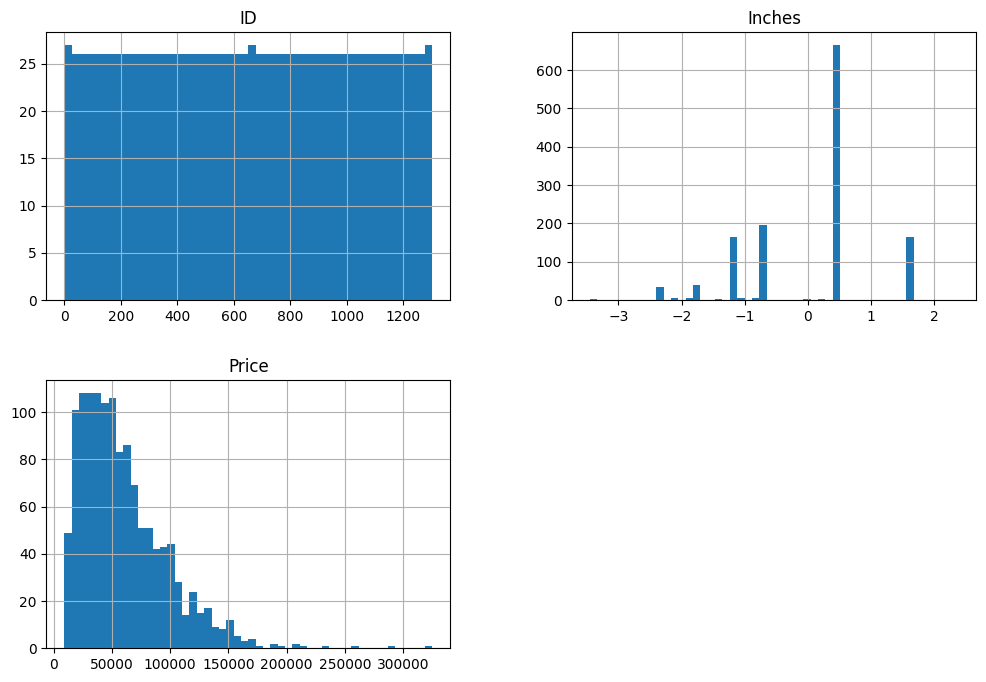

In [ ]:
ld.hist(bins=50, figsize=(12,8))
plt.show()

Few brands (e.g., < 20) - One-hot encoding
Many brands (e.g., > 50)-  Target encoding
Using tree-based models - One-hot is often safer
Using linear models	- Target encoding may help
Categories have pricing hierarchy (e.g., Apple > Lenovo) - Target encoding

In [ ]:
def frequency_encoding(df, column):
  frequencies = df[column].value_counts(normalize=True)
  encoded_column = df[column].map(frequencies)
  df[column + '_freq_encoded'] = encoded_column
  return df
ld = frequency_encoding(ld, 'Company')

In [ ]:
ld.tail(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Company_freq_encoded
1300,1300,Lenovo,Notebook,-0.713439,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12,0.227936
1301,1301,HP,Notebook,0.408772,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92,0.210284
1302,1302,Asus,Notebook,0.408772,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32,0.121259


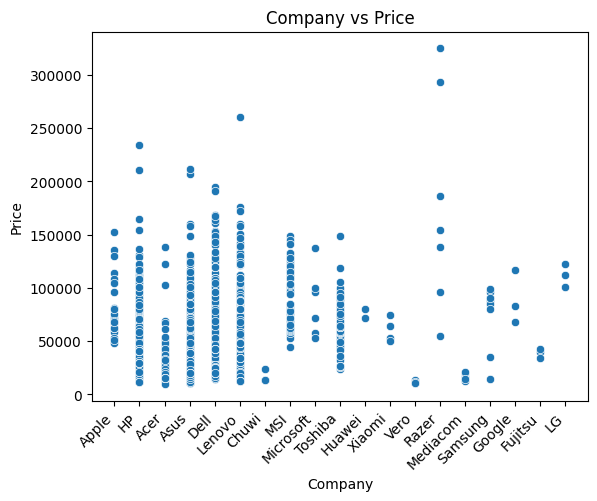

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
sns.scatterplot(x='Company', y='Price', data=ld)

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Company vs Price')
plt.xlabel('Company')
plt.ylabel('Price')

# Display the plot
plt.show()

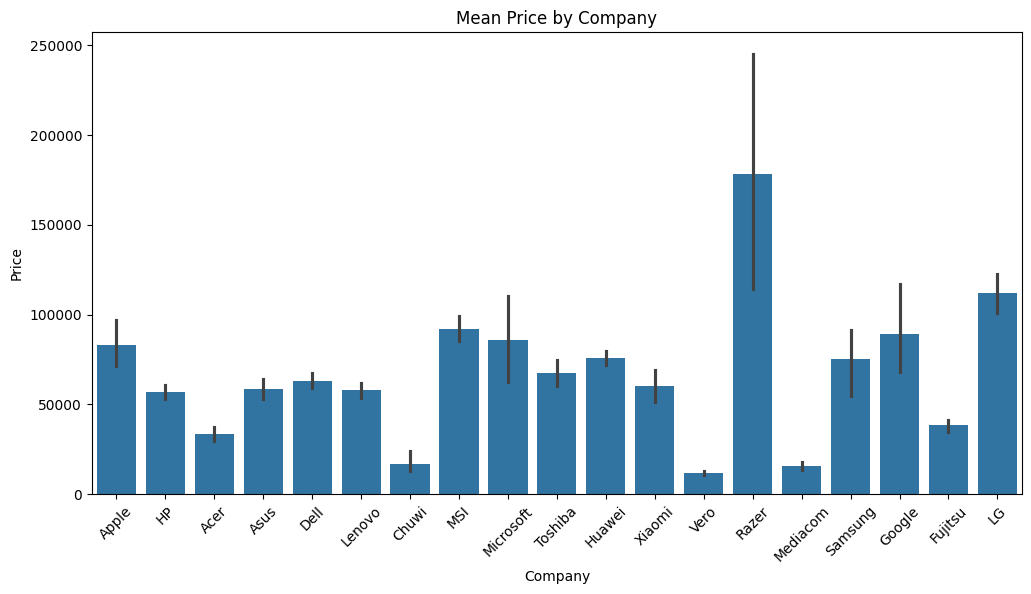

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=ld,
    x='Company',
    y='Price',
    estimator='mean'
)

plt.xticks(rotation=45)
plt.title("Mean Price by Company")
plt.show()

In [ ]:
lp_type_means = ld.groupby('Company')['Price'].mean()
ld['Company_cat_encoded'] = ld['Company'].map(lp_type_means)

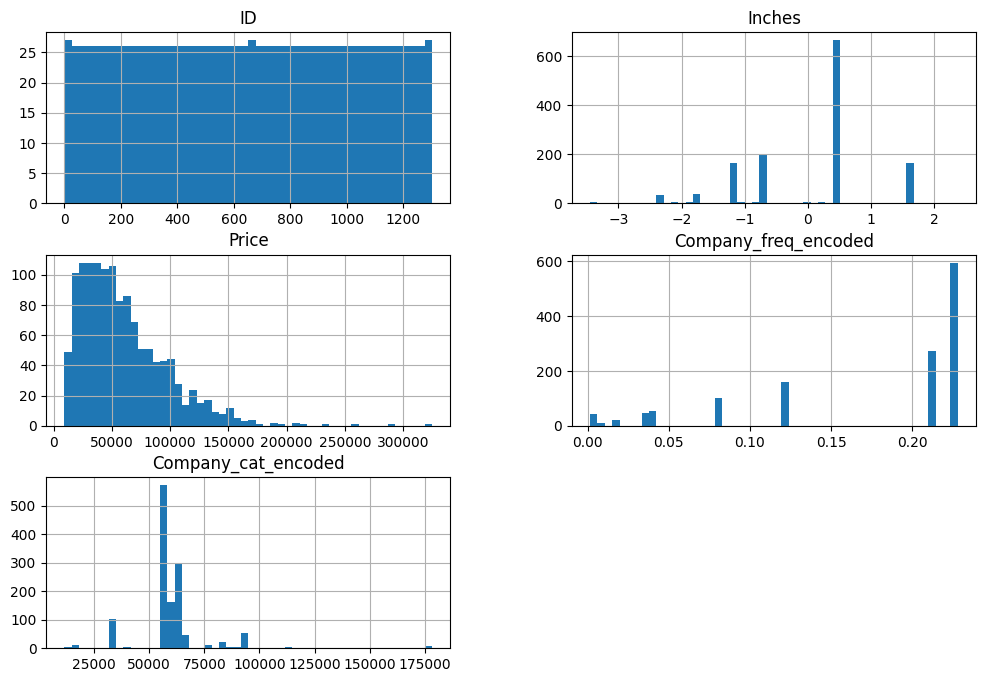

In [ ]:
ld.hist(bins=50, figsize=(12,8))
plt.show()

In [ ]:
ld['CPU_Brand'] = ld['Cpu'].str.extract(r'(^\w+)')         # Intel, AMD, Apple
ld['CPU_Series'] = ld['Cpu'].str.extract(r'(i\d| \d)') # i3, i5, Ryzen 5, etc.

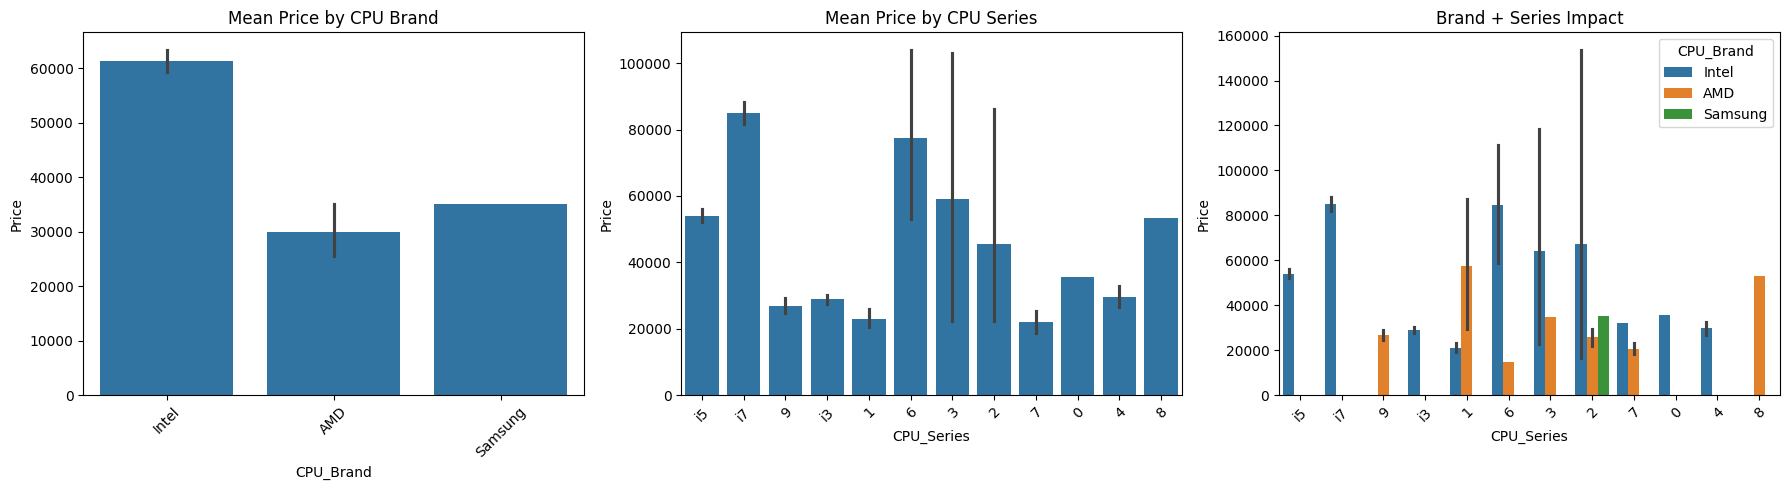

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# Brand Impact
plt.subplot(1,3,1)
sns.barplot(
    data=ld,
    x='CPU_Brand',
    y='Price',
    estimator='mean'
)
plt.title("Mean Price by CPU Brand")
plt.xticks(rotation=45)


# Series Impact
plt.subplot(1,3,2)
sns.barplot(
    data=ld,
    x='CPU_Series',
    y='Price',
    estimator='mean'
)
plt.title("Mean Price by CPU Series")
plt.xticks(rotation=45)


# Combined Effect
plt.subplot(1,3,3)
sns.barplot(
    data=ld,
    x='CPU_Series',
    y='Price',
    hue='CPU_Brand',
    estimator='mean'
)
plt.title("Brand + Series Impact")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   object 
 2   TypeName              1303 non-null   object 
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   object 
 5   Cpu                   1303 non-null   object 
 6   Ram                   1303 non-null   object 
 7   Memory                1303 non-null   object 
 8   Gpu                   1303 non-null   object 
 9   OpSys                 1303 non-null   object 
 10  Weight                1303 non-null   object 
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   object 
 15  CPU_Series           

Mean Price by Brand:

CPU_Brand
AMD        29870.839045
Intel      61389.969654
Samsung    35111.520000
Name: Price, dtype: float64 

Mean Price by Family:

CPU_Family
A10-Series     30599.680800
A12-Series     34902.196200
A4-Series      20193.120000
A6-Series      21570.068945
A8-Series      23896.080000
A9-Series      26009.603576
Atom           16778.527754
Celeron        17013.823691
Core           66016.502995
Cortex         35111.520000
E-Series       16031.300800
FX             45234.720000
Pentium        23205.571200
Ryzen          89803.440000
Xeon          190955.520000
Name: Price, dtype: float64 

Correlation between GHz and Price:
          CPU_GHz     Price
CPU_GHz  1.000000  0.430293
Price    0.430293  1.000000 



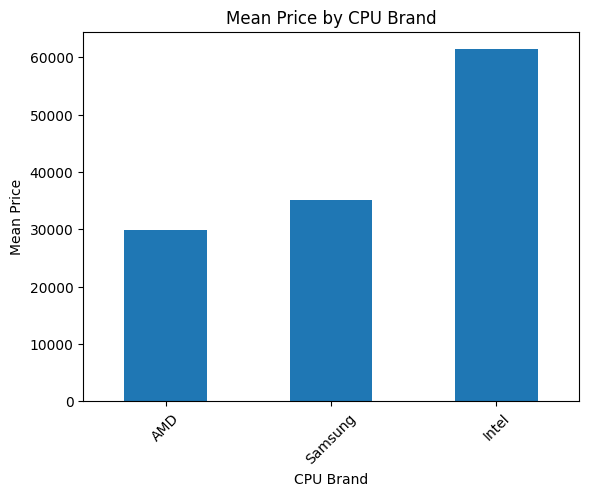

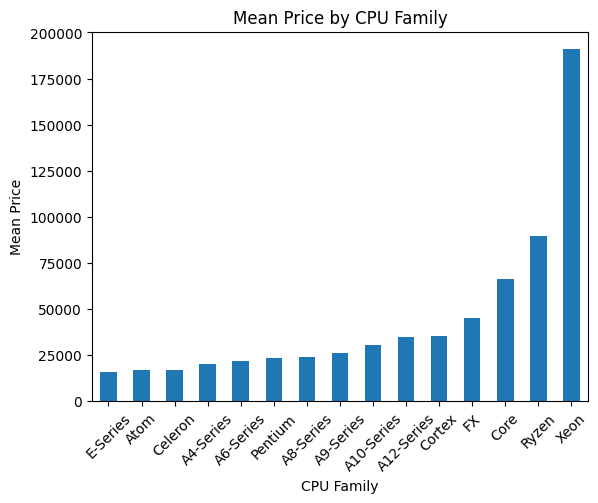

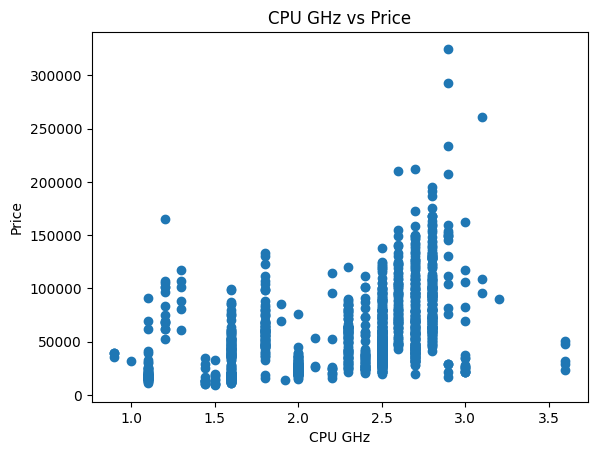

In [ ]:
import re
ld = ld.copy()

# ============================================================
# CLEAN STRUCTURED CPU PARSER (Brand, Family, Model, GHz)
# ============================================================

def clean_cpu_parser(cpu_string):
    if pd.isna(cpu_string):
        return pd.Series([None]*4,
                         index=['CPU_Brand','CPU_Family','CPU_Model','CPU_GHz'])

    tokens = cpu_string.split()

    # Brand
    brand = tokens[0]

    # Extract GHz
    ghz_match = re.search(r'(\d+\.?\d*)\s?GHz', cpu_string)
    ghz = float(ghz_match.group(1)) if ghz_match else None

    # Remove GHz for cleaner parsing
    cpu_clean = re.sub(r'(\d+\.?\d*)\s?GHz', '', cpu_string).strip()
    tokens = cpu_clean.split()

    # Family (second token if exists)
    family = tokens[1] if len(tokens) > 1 else None

    # Model (last token containing digit)
    model = None
    for t in reversed(tokens):
        if re.search(r'\d', t):
            model = t
            break

    return pd.Series([brand, family, model, ghz],
                     index=['CPU_Brand','CPU_Family','CPU_Model','CPU_GHz'])

ld[['CPU_Brand','CPU_Family','CPU_Model','CPU_GHz']] = ld['Cpu'].apply(clean_cpu_parser)

# ============================================================
# NUMERIC IMPACT ANALYSIS
# ============================================================

print("Mean Price by Brand:\n")
print(ld.groupby('CPU_Brand')['Price'].mean(), "\n")

print("Mean Price by Family:\n")
print(ld.groupby('CPU_Family')['Price'].mean(), "\n")

print("Correlation between GHz and Price:")
print(ld[['CPU_GHz','Price']].corr(), "\n")

# ============================================================
# PLOT 1 — Brand Impact
# ============================================================

brand_mean = ld.groupby('CPU_Brand')['Price'].mean().sort_values()

plt.figure()
brand_mean.plot(kind='bar')
plt.title("Mean Price by CPU Brand")
plt.xlabel("CPU Brand")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PLOT 2 — Family Impact
# ============================================================

family_mean = ld.groupby('CPU_Family')['Price'].mean().sort_values()

plt.figure()
family_mean.plot(kind='bar')
plt.title("Mean Price by CPU Family")
plt.xlabel("CPU Family")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PLOT 3 — GHz Impact (Scatter)
# ============================================================

plt.figure()
plt.scatter(ld['CPU_GHz'], ld['Price'])
plt.title("CPU GHz vs Price")
plt.xlabel("CPU GHz")
plt.ylabel("Price")
plt.show()

In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   object 
 2   TypeName              1303 non-null   object 
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   object 
 5   Cpu                   1303 non-null   object 
 6   Ram                   1303 non-null   object 
 7   Memory                1303 non-null   object 
 8   Gpu                   1303 non-null   object 
 9   OpSys                 1303 non-null   object 
 10  Weight                1303 non-null   object 
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   object 
 15  CPU_Series           

In [ ]:
ld['CPU_Brand'] = ld['CPU_Brand'].fillna('Unknown')
ld['CPU_Family'] = ld['CPU_Family'].fillna('Unknown')
ld['CPU_Model'] = ld['CPU_Model'].fillna('Unknown')
# If still missing
ld['CPU_GHz'] = ld['CPU_GHz'].fillna(ld['CPU_GHz'].median())

In [ ]:
import  category_encoders as ce
ld_feat = ld.copy()

# ------------------------------------------------------------
# Convert Brand into single numeric feature (Target Mean)
# ------------------------------------------------------------

brand_mean = ld_feat.groupby('CPU_Brand')['Price'].mean()
ld_feat['CPU_Brand_TE'] = ld_feat['CPU_Brand'].map(brand_mean)

# ------------------------------------------------------------
# Convert Family into single numeric feature (Target Mean)
# ------------------------------------------------------------

family_mean = ld_feat.groupby('CPU_Family')['Price'].mean()
ld_feat['CPU_Family_TE'] = ld_feat['CPU_Family'].map(family_mean)

# ------------------------------------------------------------
# Convert Model into single numeric feature (Target Mean)
# ------------------------------------------------------------

model_mean = ld_feat.groupby('CPU_Model')['Price'].mean()
ld_feat['CPU_Model_TE'] = ld_feat['CPU_Model'].map(model_mean)


# ------------------------------------------------------------
# Convert Model into numeric generation proxy (extract leading digits)
# ------------------------------------------------------------

ld_feat['CPU_Model_Num'] = (
    ld_feat['CPU_Model']
    .str.extract(r'(\d+)')[0]
)
ld_feat['CPU_Model_Num'] = pd.to_numeric(ld_feat['CPU_Model_Num'], errors='coerce')


#------------------------------------------------------------
# overall impact
#------------------------------------------------------------
encoder = ce.TargetEncoder(cols=['Cpu'])

ld_feat['CPU_TE']= ld['CPU_TE'] = encoder.fit_transform(
    ld[['Cpu']],    # double brackets
    ld['Price']
)

# ------------------------------------------------------------
#Compute Correlations with Price
# ------------------------------------------------------------

features = ['CPU_GHz','CPU_Brand_TE','CPU_Family_TE','CPU_Model_Num','CPU_Model_TE','CPU_TE','Price']

corr_values = ld_feat[features].corr()['Price'].sort_values(ascending=False)

print("Feature-Level Correlation with Price:\n")
print(corr_values)

Feature-Level Correlation with Price:

Price            1.000000
CPU_Model_TE     0.799813
CPU_TE           0.654484
CPU_Family_TE    0.477055
CPU_GHz          0.430293
CPU_Brand_TE     0.181168
CPU_Model_Num    0.166272
Name: Price, dtype: float64


In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   object 
 2   TypeName              1303 non-null   object 
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   object 
 5   Cpu                   1303 non-null   object 
 6   Ram                   1303 non-null   int64  
 7   Memory                1303 non-null   object 
 8   Gpu                   1303 non-null   object 
 9   OpSys                 1303 non-null   object 
 10  Weight                1303 non-null   float64
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   object 
 15  CPU_Series           

In [ ]:
ld1 = ld.copy()
ld1.info()
ld1.drop(columns=['Cpu'], inplace=True)
ld1.drop(columns=['Company'], inplace=True)
ld1.drop(columns=['Company_freq_encoded'], inplace=True)
ld1.drop(columns=['ID'], inplace=True)
ld1.drop(columns=['CPU_Brand'], inplace=True)
ld1.drop(columns=['CPU_Family'], inplace=True)
ld1.drop(columns=['CPU_Model'], inplace=True)
ld1.drop(columns=['CPU_Series'], inplace=True)
ld1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   object 
 2   TypeName              1303 non-null   object 
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   object 
 5   Cpu                   1303 non-null   object 
 6   Ram                   1303 non-null   object 
 7   Memory                1303 non-null   object 
 8   Gpu                   1303 non-null   object 
 9   OpSys                 1303 non-null   object 
 10  Weight                1303 non-null   object 
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   object 
 15  CPU_Series           

In [ ]:
ld['GPU_Brand'] = ld['Gpu'].str.extract(r'(^\w+)')         # NVidia, Intel
ld['GPU_Series'] = ld['Gpu'].str.extract(r'(i\d|Quadro \d)') # i3, i5, Ryzen 5, etc.

# 2. Encode them
from sklearn.preprocessing import OneHotEncoder
df_encoded = pd.get_dummies(ld[['GPU_Brand', 'GPU_Series']], drop_first=True)

import category_encoders as ce

# 3. Target encode full CPU string
encoder = ce.TargetEncoder(cols=['Gpu'])
ld['GPU_TE'] = encoder.fit_transform(ld['Gpu'], ld['Price'])

In [ ]:
cpu_type_means = ld.groupby('Cpu')['Price'].mean()
ld['CPU_cat_encoded'] = ld['Cpu'].map(cpu_type_means)

In [ ]:
gpu_type_means = ld.groupby('Gpu')['Price'].mean()
ld['GPU_cat_encoded'] = ld['Gpu'].map(gpu_type_means)

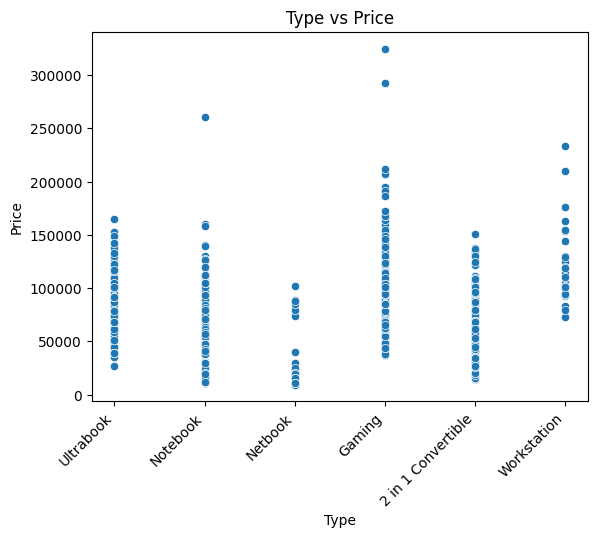

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
sns.scatterplot(x='TypeName', y='Price', data=ld)

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Type vs Price')
plt.xlabel('Type')
plt.ylabel('Price')

# Display the plot
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for a dense array
encoded_data = encoder.fit_transform(ld[['TypeName']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['TypeName']))
ld = pd.concat([ld, encoded_df], axis=1)
print(ld.head())

   ID Company   TypeName    Inches                    ScreenResolution  \
0   0   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   
1   1   Apple  Ultrabook -1.204407                            1440x900   
2   2      HP   Notebook  0.408772                   Full HD 1920x1080   
3   3   Apple  Ultrabook  0.268495  IPS Panel Retina Display 2880x1800   
4   4   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   

                          Cpu  Ram               Memory  \
0        Intel Core i5 2.3GHz    8            128GB SSD   
1        Intel Core i5 1.8GHz    8  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz    8            256GB SSD   
3        Intel Core i7 2.7GHz   16            512GB SSD   
4        Intel Core i5 3.1GHz    8            256GB SSD   

                            Gpu  OpSys  ...  GPU_Series        GPU_TE  \
0  Intel Iris Plus Graphics 640  macOS  ...         NaN  67767.161692   
1        Intel HD Graphics 6000  macOS  ...         Na

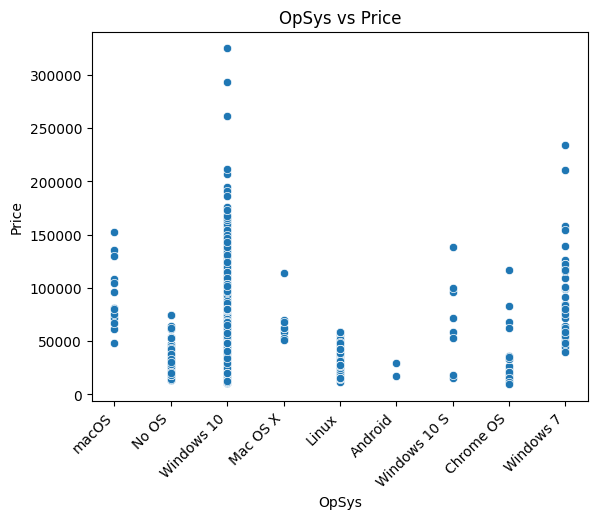

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
sns.scatterplot(x='OpSys', y='Price', data=ld)

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('OpSys vs Price')
plt.xlabel('OpSys')
plt.ylabel('Price')

# Display the plot
plt.show()

In [ ]:
ld.info()

NameError: name 'ld' is not defined

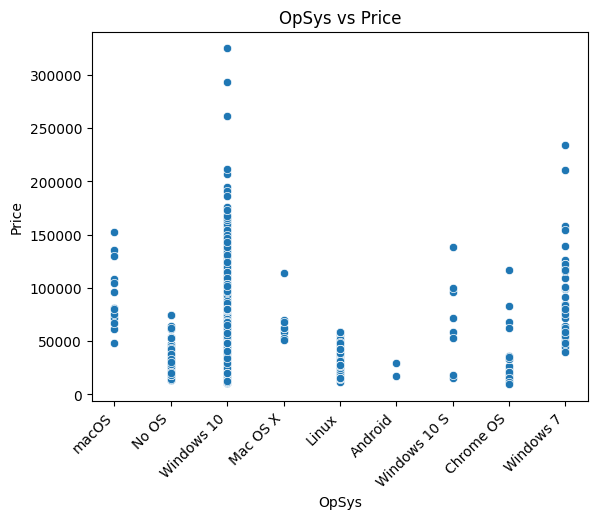

In [ ]:
sns.scatterplot(x='OpSys', y='Price', data=ld)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('OpSys vs Price')
plt.xlabel('OpSys')
plt.ylabel('Price')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for a dense array
encoded_data = encoder.fit_transform(ld[['OpSys']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['OpSys']))
ld = pd.concat([ld, encoded_df], axis=1)
print(ld.head())

   ID Company   TypeName    Inches                    ScreenResolution  \
0   0   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   
1   1   Apple  Ultrabook -1.204407                            1440x900   
2   2      HP   Notebook  0.408772                   Full HD 1920x1080   
3   3   Apple  Ultrabook  0.268495  IPS Panel Retina Display 2880x1800   
4   4   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   

                          Cpu  Ram               Memory  \
0        Intel Core i5 2.3GHz    8            128GB SSD   
1        Intel Core i5 1.8GHz    8  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz    8            256GB SSD   
3        Intel Core i7 2.7GHz   16            512GB SSD   
4        Intel Core i5 3.1GHz    8            256GB SSD   

                            Gpu  OpSys  ...  TypeName_Workstation  \
0  Intel Iris Plus Graphics 640  macOS  ...                   0.0   
1        Intel HD Graphics 6000  macOS  ...                   

In [ ]:
def frequency_encoding(df, column):
  """
  Applies frequency encoding to a categorical column in a DataFrame.

  Args:
    df: The pandas DataFrame containing the data.
    column: The name of the categorical column to encode.

  Returns:
    The DataFrame with the frequency encoded column added.
  """
  # Calculate frequency of each category
  frequencies = df[column].value_counts(normalize=True)

  # Map frequencies to the original column
  encoded_column = df[column].map(frequencies)

  # Add the encoded column to the DataFrame
  df[column + '_freq_encoded'] = encoded_column

  return df

# Apply frequency encoding to the 'CPU_cat' column in your DataFrame 'ld1'
ld1 = frequency_encoding(ld, 'ScreenResolution')

# Display the updated DataFrame
print(ld.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             1303 non-null   int64  
 1   Company                        1303 non-null   object 
 2   TypeName                       1303 non-null   object 
 3   Inches                         1303 non-null   float64
 4   ScreenResolution               1303 non-null   object 
 5   Cpu                            1303 non-null   object 
 6   Ram                            1303 non-null   int64  
 7   Memory                         1303 non-null   object 
 8   Gpu                            1303 non-null   object 
 9   OpSys                          1303 non-null   object 
 10  Weight                         1303 non-null   float64
 11  Price                          1303 non-null   float64
 12  Company_freq_encoded           1303 non-null   f

In [ ]:
import pandas as pd
import category_encoders as ce
import re

# 1. Extract Display Type and Size
def extract_display_info(resolution_string):
    """Extracts display type and size from the ScreenResolution string."""
    match = re.search(r'(\d+)x(\d+)\s*(.*)', resolution_string)
    if match:
        width, height, display_info = match.groups()
        display_type = display_info.strip()  # Assuming display type is the remaining string
        display_size = '' # Placeholder for display size logic
        return display_type, display_size
    else:
        return '', ''

ld[['DisplayType', 'DisplaySize']] = ld['ScreenResolution'].apply(extract_display_info).apply(pd.Series)


# 2. Combo Target Encoding
combo_cols = ['ScreenResolution', 'DisplayType', 'DisplaySize']

# Initialize the TargetEncoder with smoothing
encoder = ce.TargetEncoder(cols=combo_cols, smoothing=10)  # Adjust smoothing as needed

# Fit the encoder on your training data
encoder.fit(ld[combo_cols], ld['Price'])

# Transform the columns and select only the 'ScreenResolution' encoded column
# Instead of assigning the entire DataFrame, select the desired column:
ld['ScreenResolution_combo_encoded'] = encoder.transform(ld[combo_cols])['ScreenResolution']

#ld1['ScreenResolution_combo_encoded'] = encoder.transform(ld1[combo_cols])

In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1303 non-null   int64  
 1   Company                         1303 non-null   object 
 2   TypeName                        1303 non-null   object 
 3   Inches                          1303 non-null   float64
 4   ScreenResolution                1303 non-null   object 
 5   Cpu                             1303 non-null   object 
 6   Ram                             1303 non-null   int64  
 7   Memory                          1303 non-null   object 
 8   Gpu                             1303 non-null   object 
 9   OpSys                           1303 non-null   object 
 10  Weight                          1303 non-null   float64
 11  Price                           1303 non-null   float64
 12  Company_freq_encoded            13

In [ ]:
# Get a list of columns with object dtype
object_cols = ld.select_dtypes(include=['object']).columns

# Drop the object columns
ld = ld.drop(columns=object_cols)

In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1303 non-null   int64  
 1   Inches                          1303 non-null   float64
 2   Ram                             1303 non-null   int64  
 3   Weight                          1303 non-null   float64
 4   Price                           1303 non-null   float64
 5   Company_freq_encoded            1303 non-null   float64
 6   Company_cat_encoded             1303 non-null   float64
 7   CPU_TE                          1303 non-null   float64
 8   GPU_TE                          1303 non-null   float64
 9   CPU_cat_encoded                 1303 non-null   float64
 10  GPU_cat_encoded                 1303 non-null   float64
 11  TypeName_2 in 1 Convertible     1303 non-null   float64
 12  TypeName_Gaming                 13

In [ ]:
ld = ld.drop(columns=["Company_freq_encoded"])

In [ ]:
ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1303 non-null   int64  
 1   Inches                          1303 non-null   float64
 2   Ram                             1303 non-null   int64  
 3   Weight                          1303 non-null   float64
 4   Price                           1303 non-null   float64
 5   Company_cat_encoded             1303 non-null   float64
 6   CPU_TE                          1303 non-null   float64
 7   GPU_TE                          1303 non-null   float64
 8   CPU_cat_encoded                 1303 non-null   float64
 9   GPU_cat_encoded                 1303 non-null   float64
 10  TypeName_2 in 1 Convertible     1303 non-null   float64
 11  TypeName_Gaming                 1303 non-null   float64
 12  TypeName_Netbook                13

In [ ]:
ld = ld.drop(columns=["CPU_cat_encoded"])
ld = ld.drop(columns=["GPU_cat_encoded"])

In [ ]:
ld =ld.drop(columns="ScreenResolution_freq_encoded")

In [ ]:
ld =ld.drop(columns="ID")

In [ ]:
ld1=ld.copy()

In [ ]:
ld1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Inches                          1303 non-null   float64
 1   Ram                             1303 non-null   int64  
 2   Weight                          1303 non-null   float64
 3   Price                           1303 non-null   float64
 4   Company_cat_encoded             1303 non-null   float64
 5   CPU_TE                          1303 non-null   float64
 6   GPU_TE                          1303 non-null   float64
 7   TypeName_2 in 1 Convertible     1303 non-null   float64
 8   TypeName_Gaming                 1303 non-null   float64
 9   TypeName_Netbook                1303 non-null   float64
 10  TypeName_Notebook               1303 non-null   float64
 11  TypeName_Ultrabook              1303 non-null   float64
 12  TypeName_Workstation            13

In [ ]:
print(ld1.head(2))

     Inches  Ram  Weight       Price  Company_cat_encoded        CPU_TE  \
0 -1.204407    8    1.37  71378.6832         83340.499886  62178.452057   
1 -1.204407    8    1.34  47895.5232         83340.499886  59153.054815   

         GPU_TE  TypeName_2 in 1 Convertible  TypeName_Gaming  \
0  67767.161692                          0.0              0.0   
1  58888.758674                          0.0              0.0   

   TypeName_Netbook  ...  OpSys_Android  OpSys_Chrome OS  OpSys_Linux  \
0               0.0  ...            0.0              0.0          0.0   
1               0.0  ...            0.0              0.0          0.0   

   OpSys_Mac OS X  OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  \
0             0.0          0.0               0.0                 0.0   
1             0.0          0.0               0.0                 0.0   

   OpSys_Windows 7  OpSys_macOS  ScreenResolution_combo_encoded  
0              0.0          1.0                    65732.926374  
1        

In [ ]:
# Save the modified DataFrame back to a CSV file
ld1.to_csv("laptop_data_m.csv", index=False)

In [ ]:
corr_matrix = ld1.corr()
corr_matrix["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
CPU_TE,0.654484
GPU_TE,0.649540
ScreenResolution_combo_encoded,0.545037
Company_cat_encoded,0.404350
TypeName_Gaming,0.375789
TypeName_Ultrabook,0.255658
TypeName_Workstation,0.249752
Weight,0.210370


In [ ]:
import numpy as np
ld1["price_cat"] = pd.cut(ld1["Price"],
                               bins=[0., 50000.0, 100000.0,np.inf],
                               labels=[1, 2, 3])

In [ ]:
ld1["price_cat"].value_counts()

,count
price_cat,
1,623
2,503
3,177


In [ ]:
import numpy as np
ld1["price_cat"] = pd.cut(ld1["Price"],
                               bins=[0., 50000.0, 100000.0,np.inf],
                               labels=[1, 2, 3])

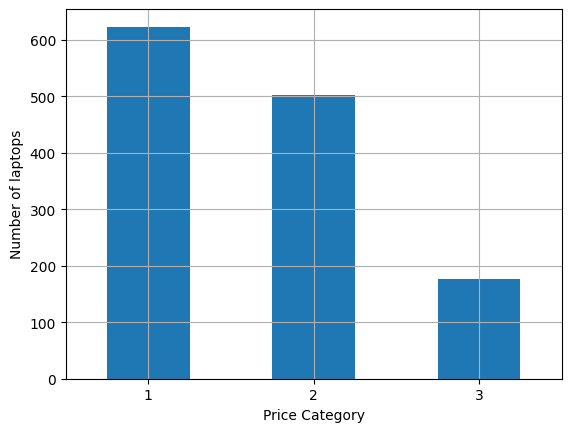

In [ ]:
ld1["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Price Category")
plt.ylabel("Number of laptops")
plt.show()

# Machine Learning

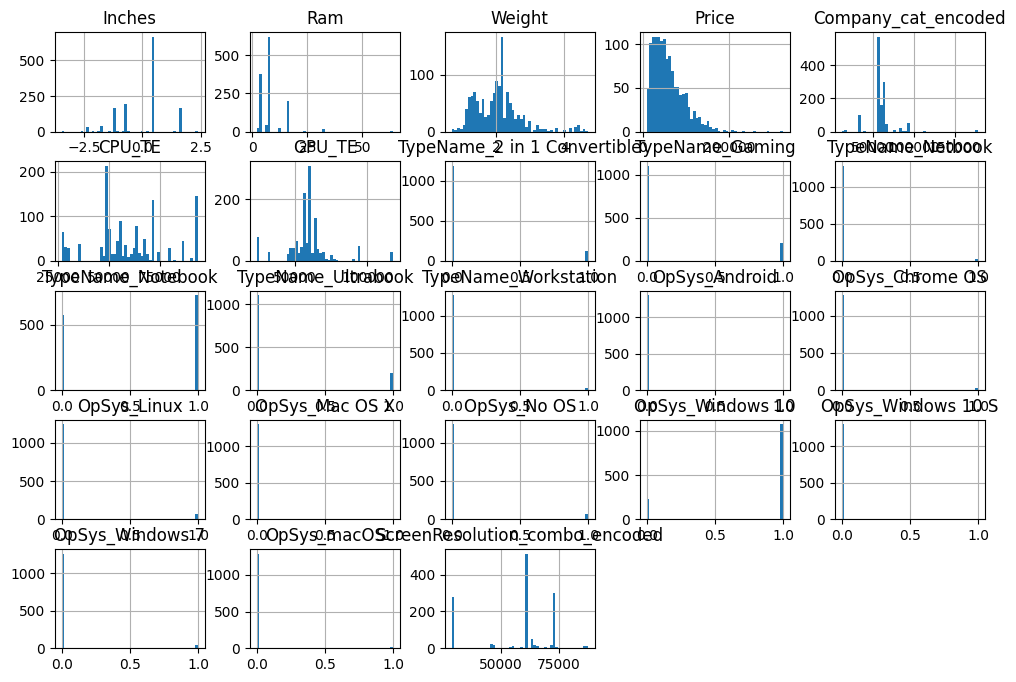

In [ ]:
ld1.hist(bins=50, figsize=(12,8))
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []  # To store multiple splits

for train_index, test_index in splitter.split(ld1, ld1["price_cat"]):
    strat_train_set_n = ld1.iloc[train_index]
    strat_test_set_n = ld1.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [ ]:
strat_train_set, strat_test_set = strat_splits[0]
print(strat_train_set.sample())
print("training set shape:", strat_train_set.shape)
print("testing set shape: ", strat_test_set.shape)

       Inches  Ram  Weight    Price  Company_cat_encoded        CPU_TE  \
961 -1.765512    8    1.36  93772.8           57882.5632  62421.857223   

           GPU_TE  TypeName_2 in 1 Convertible  TypeName_Gaming  \
961  60801.454172                          0.0              0.0   

     TypeName_Netbook  ...  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  \
961               0.0  ...              0.0          0.0             0.0   

     OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  \
961          0.0               1.0                 0.0              0.0   

     OpSys_macOS  ScreenResolution_combo_encoded  price_cat  
961          0.0                     72203.31165          2  

[1 rows x 24 columns]
training set shape: (1042, 24)
testing set shape:  (261, 24)


In [ ]:
strat_test_set["price_cat"].value_counts() / len(strat_test_set)

,count
price_cat,
1,0.478927
2,0.386973
3,0.134100


In [ ]:
strat_train_set["price_cat"].value_counts() / len(strat_train_set)

,count
price_cat,
1,0.477927
2,0.385797
3,0.136276


In [ ]:
ld1["price_cat"].value_counts() / len(ld1)

,count
price_cat,
1,0.478127
2,0.386032
3,0.135840


In [ ]:
ld2=strat_train_set.copy()

In [ ]:
ld2 = strat_test_set.drop("Price", axis=1)
ld2_labels= strat_test_set["Price"].copy()
print (ld2.head(2))

       Inches  Ram  Weight  Company_cat_encoded        CPU_TE         GPU_TE  \
955  1.601121   16    4.36         63193.755782  93794.446472  117833.444408   
127 -0.713439    4    1.65         58830.143878  54007.519550   51696.911436   

     TypeName_2 in 1 Convertible  TypeName_Gaming  TypeName_Netbook  \
955                          0.0              1.0               0.0   
127                          0.0              0.0               0.0   

     TypeName_Notebook  ...  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  \
955                0.0  ...              0.0          0.0             0.0   
127                1.0  ...              0.0          0.0             0.0   

     OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  \
955          0.0               1.0                 0.0              0.0   
127          0.0               0.0                 1.0              0.0   

     OpSys_macOS  ScreenResolution_combo_encoded  price_cat  
955          0.0         

In [ ]:
print("cleaning data")

cleaning data


In [ ]:
ld1 = strat_train_set.drop("Price", axis=1)
ld1_labels= strat_train_set["Price"].copy()
print (ld1.head(2))

       Inches  Ram  Weight  Company_cat_encoded        CPU_TE        GPU_TE  \
47   1.601121    8     3.2         58830.143878  64467.651647  65454.097879   
118  1.601121    4     2.0         58830.143878  26812.508832  51225.685222   

     TypeName_2 in 1 Convertible  TypeName_Gaming  TypeName_Netbook  \
47                           0.0              1.0               0.0   
118                          0.0              0.0               0.0   

     TypeName_Notebook  ...  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  \
47                 0.0  ...              0.0          0.0             0.0   
118                1.0  ...              0.0          0.0             0.0   

     OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  \
47           0.0               1.0                 0.0              0.0   
118          0.0               1.0                 0.0              0.0   

     OpSys_macOS  ScreenResolution_combo_encoded  price_cat  
47           0.0            

In [ ]:
ld1=ld1.drop(columns="price_cat")

In [ ]:
ld2=ld2.drop(columns="price_cat")

In [ ]:
ld1_labels= strat_train_set["Price"].copy()
print (ld1.head(2))

NameError: name 'strat_train_set' is not defined

In [ ]:
print(ld1.head(2))

       Inches  Ram  Weight  Company_cat_encoded        CPU_TE        GPU_TE  \
47   1.601121    8     3.2         58830.143878  64467.651647  65454.097879   
118  1.601121    4     2.0         58830.143878  26812.508832  51225.685222   

     TypeName_2 in 1 Convertible  TypeName_Gaming  TypeName_Netbook  \
47                           0.0              1.0               0.0   
118                          0.0              0.0               0.0   

     TypeName_Notebook  ...  OpSys_Android  OpSys_Chrome OS  OpSys_Linux  \
47                 0.0  ...            0.0              0.0          0.0   
118                1.0  ...            0.0              0.0          0.0   

     OpSys_Mac OS X  OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  \
47              0.0          0.0               1.0                 0.0   
118             0.0          0.0               1.0                 0.0   

     OpSys_Windows 7  OpSys_macOS  ScreenResolution_combo_encoded  
47               0.0        

### 🔍 Comparison of CV Search Methods for Hyperparameter Tuning

| Method              | Best For                                 | Speed        | Exploration     | CV Built-in |
|---------------------|-------------------------------------------|--------------|------------------|-------------|
| **Grid Search**     | Small, exact search                       | ❌ Slow       | ✅ Exhaustive     | ✅ Yes       |
| **Random Search**   | Large, quick search                       | ✅ Faster     | ✅ Partial        | ✅ Yes       |
| **Bayesian Opt.**   | Expensive models, fewer trials needed     | ✅ Fast       | ✅ Smart Search   | ⚠️ Custom    |
| **Halving Search**  | Limited resources, fast pruning           | ✅ Very Fast  | ✅ Progressive    | ✅ Yes       |
| **Hyperband**       | Deep learning, early stopping             | ✅ Very Fast  | ✅ Adaptive       | ⚠️ Custom    |
| **TPOT / Genetic**  | Feature + model + param tuning            | ⚠️ Slower     | ✅ Exploratory    | ✅ Yes       |
| **AutoML Tools**    | Automated full pipeline tuning            | ✅ Fast       | ✅ All-in-One     | ✅ Yes       |


In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=10, scoring='neg_mean_squared_error')
ridge_grid.fit(ld1, ld1_labels)
print("🔹 Best Ridge Parameters:", ridge_grid.best_params_)

🔹 Best Ridge Parameters: {'alpha': 1.0, 'solver': 'auto'}


Ridge (Regularized Linear Regression)

In [ ]:
predictions1 = ridge_grid.predict(ld2)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Create a pipeline that includes scaling and the model
pipeline = make_pipeline(StandardScaler(), RandomForestRegressor())

# Perform 10-fold cross-validation
scores = cross_val_score(pipeline, ld1, ld1_labels, cv=10, scoring='neg_mean_squared_error')

# Calculate RMSE from the negative MSE scores
rmse_scores = np.sqrt(-scores)

# Print the results
print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation of RMSE:", rmse_scores.std())

rf = RandomForestRegressor(random_state=None)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf, rf_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(ld1, ld1_labels)

print(" Best Random Forest Params:", rf_grid.best_params_)



RMSE scores: [11766.84158355 13768.20746489 14677.25377263 16273.30734353
 16273.03145028 16335.9479827  12625.46687003 22301.96823135
 17193.79670905 12990.14131575]
Mean RMSE: 15420.596272375586
Standard Deviation of RMSE: 2883.4333757612812
 Best Random Forest Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
predictions2 = rf_grid.predict(ld2)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(ld1_labels.to_frame())

model = DecisionTreeRegressor()
model.fit(ld1, scaled_labels)
#some_new_data = ld1.iloc[:5]


DecisionTreeRegressor()

In [ ]:
ld_predictions = model.predict(ld2)
predictions3 = target_scaler.inverse_transform(ld_predictions.reshape(-1,1))

In [ ]:
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(ld1_labels.values.reshape(-1,1)).ravel()

model = XGBRegressor()
model.fit(ld1, scaled_labels)
#some_new_data = ld1.iloc[:5]

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
ld_predictions = model.predict(ld2)
predictions4 = target_scaler.inverse_transform(ld_predictions.reshape(-1,1))

In [ ]:
#some_data = ld1.iloc[:5]
#some_labels = ld1_labels.iloc[:5]
print("Predictions:", predictions1[:3])
print("Predictions:", predictions2[:3])
print("Predictions:", predictions3[:3])
print("Predictions:", predictions4[:3])

Predictions: [[4.76544066e+09]
 [1.14112618e+09]
 [3.12491287e+09]]
Predictions: [[5.44524961e+09]
 [6.76735525e+08]
 [3.58065153e+09]]
Predictions: [[152161.5528]
 [ 18594.72  ]
 [ 78694.56  ]]
Predictions: [[151629.22  ]
 [ 14765.9375]
 [ 93895.21  ]]


In [ ]:
print(ld2_labels.iloc[:3])

955    168045.1200
127     14811.3072
963     95371.2000
Name: Price, dtype: float64


In [ ]:
from sklearn.metrics import mean_squared_error

# Assuming ld2_labels contains the actual target values and
# predictions1, predictions2, predictions3 are your model predictions

# Calculate RMSE for each model's predictions
rmse1 = np.sqrt(mean_squared_error(ld2_labels, predictions1))
rmse2 = np.sqrt(mean_squared_error(ld2_labels, predictions2))
rmse3 = np.sqrt(mean_squared_error(ld2_labels, predictions3))
rmse4 = np.sqrt(mean_squared_error(ld2_labels, predictions4))
print("RMSE for Model 1:", rmse1)
print("RMSE for Model 2:", rmse2)
print("RMSE for Model 3:", rmse3)
print("RMSE for Model 4:", rmse4)

RMSE for Model 1: 16978.51153142416
RMSE for Model 2: 13652.104876201267
RMSE for Model 3: 20369.317829747655
RMSE for Model 4: 12128.890646154847


do as a piplin e and do the category like housing data

In [ ]:
import numpy as np

def average_percentage_difference(actual_prices, predicted_prices):
  # Calculate the absolute differences between actual and predicted prices
  differences = np.abs(actual_prices - predicted_prices)
  average_price = (actual_prices + predicted_prices) / 2
  percentage_differences = (differences / average_price) * 100
  average_percentage_diff = np.mean(percentage_differences)
  return average_percentage_diff

actual_prices = ld2_labels
predicted_prices1 = predictions1.flatten()
avg_percentage_diff1 = average_percentage_difference(actual_prices, predicted_prices1)
print(f"Average Percentage Difference1: {avg_percentage_diff1:.2f}%")

predicted_prices2 = predictions2.flatten()
avg_percentage_diff2 = average_percentage_difference(actual_prices, predicted_prices2)
print(f"Average Percentage Difference2: {avg_percentage_diff2:.2f}%")

predicted_prices3 = predictions3.flatten()
avg_percentage_diff3 = average_percentage_difference(actual_prices, predicted_prices3)
print(f"Average Percentage Difference3: {avg_percentage_diff3:.2f}%")

predicted_prices4 = predictions4.flatten()
avg_percentage_diff4 = average_percentage_difference(actual_prices, predicted_prices4)
print(f"Average Percentage Difference3: {avg_percentage_diff4:.2f}%")

Average Percentage Difference1: 30.66%
Average Percentage Difference2: 15.14%
Average Percentage Difference3: 21.09%
Average Percentage Difference3: 13.55%
